# 99 Report Figures
Loads saved evaluation artifacts and creates final comparison tables/plots.

In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')
data_dir = Path('../data')

files = {
    'arrival_residual': data_dir / 'model_eval_summary_improved.csv',
    'arrival_segmented': data_dir / 'model_eval_summary_segmented.csv',
    'retrospective': data_dir / 'model_eval_summary_retrospective.csv'
}

frames = []
for label, path in files.items():
    if path.exists():
        tmp = pd.read_csv(path)
        tmp['source'] = label
        frames.append(tmp)

if not frames:
    raise FileNotFoundError('No evaluation summary files found. Run modeling notebooks first.')

all_eval = pd.concat(frames, ignore_index=True)
display(all_eval)

,model_name,split,mae,rmse,r2,source
0,by_hour_median_trainfit,valid,25.692697,50.744881,-0.086506,arrival_residual
1,residual_hgb,valid,25.551924,50.496751,-0.075906,arrival_residual
2,by_hour_median_trainfit,holdout,28.344885,55.999156,-0.100491,arrival_residual
3,residual_hgb,holdout,28.364057,55.902335,-0.096689,arrival_residual
4,by_hour_median_trainfit,holdout,28.344885,55.999156,-0.100491,arrival_segmented
5,segmented_hgb_by_immedr,holdout,28.372584,55.844995,-0.094440,arrival_segmented
6,by_hour_median_trainfit,holdout,28.344885,55.999156,-0.100491,retrospective
7,linear_regression,holdout,34.486214,53.475413,-0.003533,retrospective


,model_name,split,mae,rmse,r2,source
2,by_hour_median_trainfit,holdout,28.344885,55.999156,-0.100491,arrival_residual
4,by_hour_median_trainfit,holdout,28.344885,55.999156,-0.100491,arrival_segmented
6,by_hour_median_trainfit,holdout,28.344885,55.999156,-0.100491,retrospective
3,residual_hgb,holdout,28.364057,55.902335,-0.096689,arrival_residual
5,segmented_hgb_by_immedr,holdout,28.372584,55.844995,-0.094440,arrival_segmented
7,linear_regression,holdout,34.486214,53.475413,-0.003533,retrospective


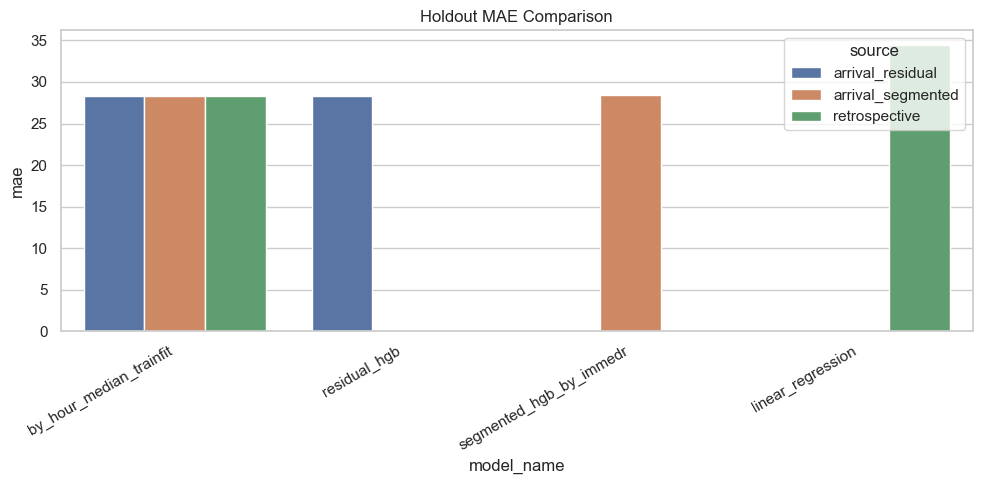

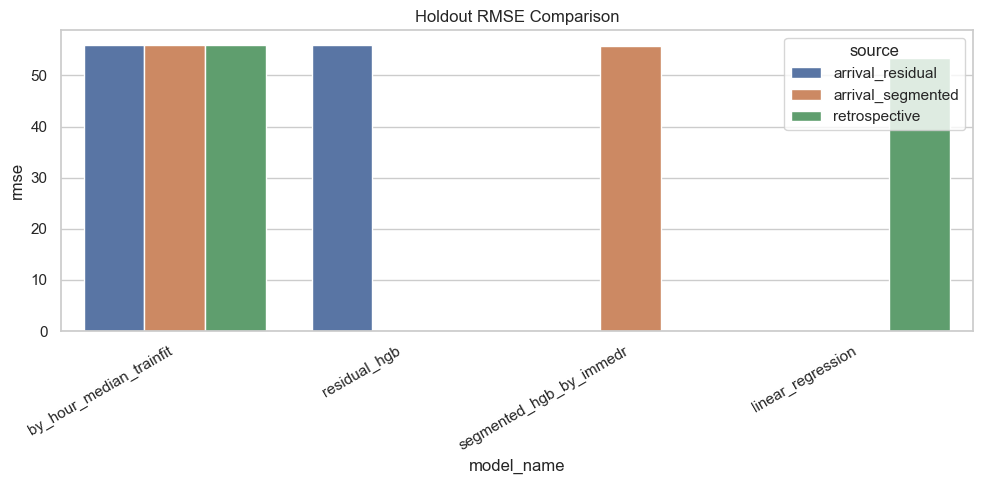

In [2]:
holdout = all_eval[all_eval['split'] == 'holdout'].copy()
holdout = holdout.sort_values('mae')
display(holdout)

plt.figure(figsize=(10, 5))
sns.barplot(data=holdout, x='model_name', y='mae', hue='source')
plt.title('Holdout MAE Comparison')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=holdout, x='model_name', y='rmse', hue='source')
plt.title('Holdout RMSE Comparison')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [3]:
best_row = holdout.iloc[0]
print('Best holdout model:')
print(best_row[['model_name', 'source', 'mae', 'rmse', 'r2']])

(data_dir / 'final_holdout_ranking.csv').write_text(holdout.to_csv(index=False))
print('Saved: data/final_holdout_ranking.csv')

Best holdout model:
model_name    by_hour_median_trainfit
source               arrival_residual
mae                         28.344885
rmse                        55.999156
r2                          -0.100491
Name: 2, dtype: object
Saved: data/final_holdout_ranking.csv
